In [13]:
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    PrecisionRecallDisplay
)

In [14]:
model = joblib.load("../models/churn_model.pkl")
scaler = joblib.load("../models/scaler.pkl")

In [15]:
rfm = pd.read_csv("../data/processed/customer_features.csv")

X = rfm.drop(columns=["Customer ID","Churn"])

y = rfm["Churn"]

In [16]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [17]:
pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]

In [18]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       579
           1       1.00      1.00      1.00       289

    accuracy                           1.00       868
   macro avg       1.00      1.00      1.00       868
weighted avg       1.00      1.00      1.00       868



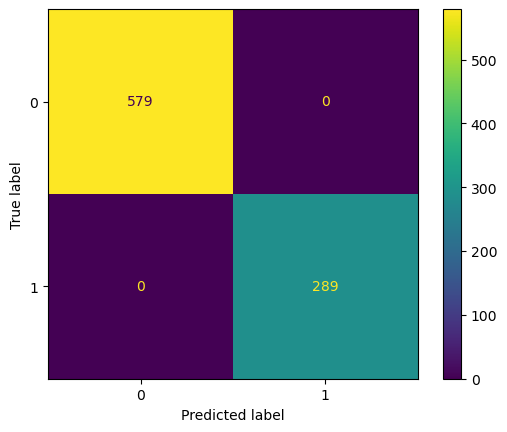

In [19]:
cm = confusion_matrix(y_test,pred)

disp = ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

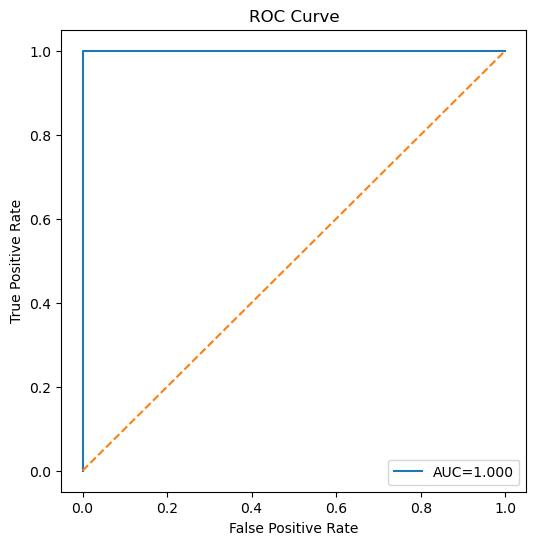

In [20]:
fpr,tpr,_ = roc_curve(y_test,prob)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label=f"AUC={roc_auc_score(y_test,prob):.3f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

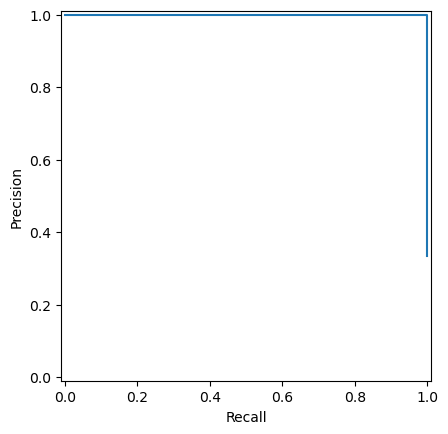

In [21]:
precision,recall,_ = precision_recall_curve(
    y_test,
    prob
)

display = PrecisionRecallDisplay(
    precision=precision,
    recall=recall
)

display.plot()

plt.show()

In [22]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,Recency,0.789280
6,CustomerLifetime,0.048434
1,Frequency,0.042948
2,Monetary,0.034525
5,UniqueProducts,0.027437
4,TotalQuantity,0.024291
7,AveragePurchaseGap,0.020997
3,AverageOrderValue,0.012088


In [23]:
metrics = pd.DataFrame({

    "Metric":[
        "ROC AUC"
    ],

    "Value":[
        roc_auc_score(y_test,prob)
    ]

})

metrics.to_csv(
    "../reports/model_metrics.csv",
    index=False
)